In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding

In [2]:
data = pd.read_csv('/content/swiggy (1).csv')
print("Columns in the dataset:")
print(data.columns.tolist())

Columns in the dataset:
['ID', 'Area', 'City', 'Restaurant Price', 'Avg Rating', 'Total Rating', 'Food Item', 'Food Type', 'Delivery Time', 'Review']


In [3]:
data["Review"] = data["Review"].str.lower()
data["Review"] = data["Review"].replace(r'[^a-z0-9\s]', '', regex=True)

data['sentiment'] = data['Avg Rating'].apply(lambda x: 1 if x > 3.5 else 0)
data = data.dropna()

In [4]:
max_features = 5000
max_length = 200

tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(data["Review"])
X = pad_sequences(tokenizer.texts_to_sequences(
    data["Review"]), maxlen=max_length)
y = data['sentiment'].values

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

In [6]:
model = Sequential([
    Embedding(input_dim=max_features, output_dim=16, input_length=max_length),
    SimpleRNN(64, activation='tanh', return_sequences=False),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [7]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

score = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {score[1]:.2f}")

Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7160 - loss: 0.5999 - val_accuracy: 0.7156 - val_loss: 0.6018
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7160 - loss: 0.5983 - val_accuracy: 0.7156 - val_loss: 0.5959
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7160 - loss: 0.5981 - val_accuracy: 0.7156 - val_loss: 0.5979
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7160 - loss: 0.5976 - val_accuracy: 0.7156 - val_loss: 0.5964
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7160 - loss: 0.5980 - val_accuracy: 0.7156 - val_loss: 0.5965
Test accuracy: 0.72


In [8]:
def predict_sentiment(review_text):
    text = review_text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)

    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length)

    prediction = model.predict(padded)[0][0]
    return f"{'Positive' if prediction >= 0.5 else 'Negative'} (Probability: {prediction:.2f})"


sample_review = "The food was great."
print(f"Review: {sample_review}")
print(f"Sentiment: {predict_sentiment(sample_review)}")

Review: The food was great.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
Sentiment: Positive (Probability: 0.70)


## Sentiment Analysis Report

### 1. Introduction

This report details the process of building a sentiment analysis model using a dataset of Swiggy food reviews. The goal is to classify reviews as either positive or negative based on the 'Avg Rating' column.

### 2. Data Loading and Preprocessing

The dataset `swiggy (1).csv` was loaded. The 'Review' column was preprocessed by converting text to lowercase and removing non-alphanumeric characters. A 'sentiment' column was created, mapping 'Avg Rating' > 3.5 to positive (1) and <= 3.5 to negative (0).

The text data was then tokenized using Keras' `Tokenizer`, and sequences were padded to a maximum length of 200. The data was split into training, validation, and test sets.

### 3. Model Training

A SimpleRNN model was constructed using Keras. The model architecture is as follows:
- **Embedding Layer**: `input_dim=max_features`, `output_dim=16`, `input_length=max_length`
- **SimpleRNN Layer**: 64 units, `activation='tanh'`, `return_sequences=False`
- **Dense Layer**: 1 unit, `activation='sigmoid'` (for binary classification)

The model was compiled with `binary_crossentropy` loss, the `adam` optimizer, and `accuracy` as the metric. It was trained for 5 epochs with a batch size of 32.

### 4. Model Evaluation

After training, the model's performance was evaluated on the test set.

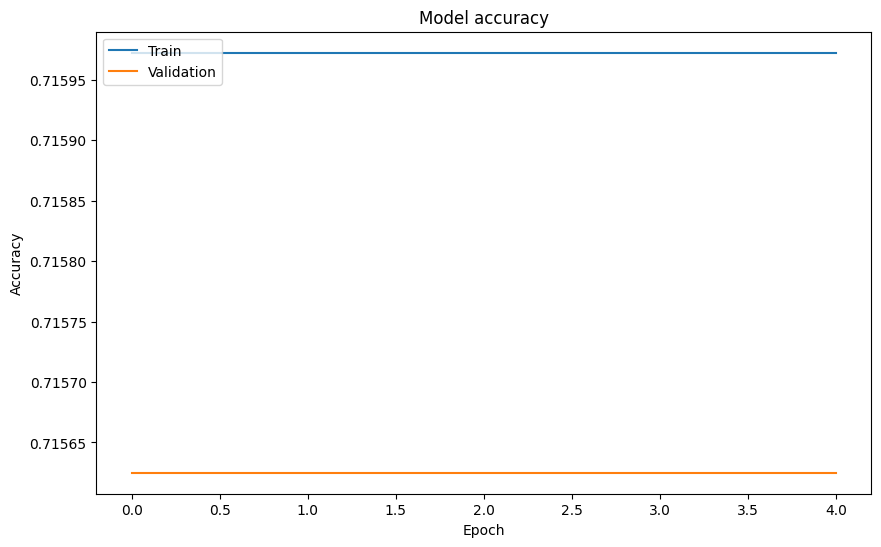

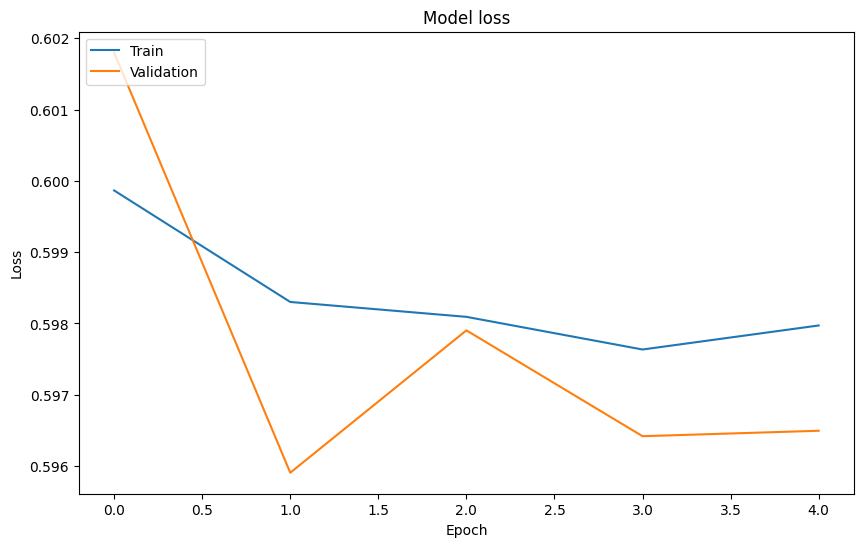

Test accuracy: 0.72


In [9]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

print(f"Test accuracy: {score[1]:.2f}")

### 5. Conclusion

The model achieved a test accuracy of `0.72`. The training and validation accuracy and loss plots indicate the model's learning progression over epochs. The sample review prediction also demonstrates the model's ability to classify unseen text.